In [10]:
import pandas as pd
from dictionaries import amino_acids, motifs
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import re

In [11]:
df = pd.read_csv("/Users/bani4ki/Documents/programming_project_bioinformatics/datasets/dataset_A.csv")

In [26]:
df.head()

,Entry,Sequence,Functional_class,Sequence_length,A_count,A_fq,R_count,R_fq,N_count,N_fq,...,S_count,S_fq,T_count,T_fq,W_count,W_fq,Y_count,Y_fq,V_count,V_fq
0,P56489,MNTSAPPAVSPNITVLAPGKGPWQVAFIGITTGLLSLATVTGNLLV...,G protein-coupled receptor,460,37.0,0.08,32.0,0.07,15.0,0.03,...,35.0,0.08,35.0,0.08,13.0,0.03,16.0,0.03,26.0,0.06
1,Q63638,MQKARGTRGEDAGTRAPPSPGVPPKRAKVGAGRGVLVTGAGAGAPV...,Kinase,3259,278.0,0.09,299.0,0.09,43.0,0.01,...,342.0,0.10,177.0,0.05,35.0,0.01,57.0,0.02,217.0,0.07
2,O46560,MQAGSWVVGGGDSDSRVLSIQSHVVRGYVGNRAATFPLQVLGFEVD...,Kinase,322,25.0,0.08,18.0,0.06,11.0,0.03,...,20.0,0.06,15.0,0.05,4.0,0.01,10.0,0.03,39.0,0.12
3,E7FEL0,MASLRGSETMCNITTSCNVDSNIDQFFQPTLYIIVIVLGFPTNCMA...,G protein-coupled receptor,373,30.0,0.08,15.0,0.04,18.0,0.05,...,18.0,0.05,21.0,0.06,7.0,0.02,16.0,0.04,29.0,0.08
4,Q63562,MEYMSTGSDEKEEIDLLINHLNVSEVLDIMENLYASEEPAVYEPSL...,Kinase,467,26.0,0.06,26.0,0.06,16.0,0.03,...,38.0,0.08,19.0,0.04,5.0,0.01,19.0,0.04,28.0,0.06


- sequence length,
- number of occurrences of each amino acid,
- frequency of each amino acid,
- proportion of hydrophobic amino acids,
- proportion of charged amino acids, or
- other sequence-derived features.

In [21]:
df["Sequence_length"] = df["Sequence"].str.len()

In [22]:
def amino_acid_composition(sequence, amino_acids):
    metrics = {}
    sequence = sequence.upper()
    
    for aa in amino_acids.keys():
        count = sequence.count(aa)
        metrics[f"{aa}_count"] = count
        frequency = count/len(sequence)
        metrics[f"{aa}_fq"] = round(frequency, 2)    

    return metrics

Test function:

In [17]:
print(amino_acid_composition("NTSAPPAVSPNITVLAPGKGPW", amino_acids))

{'A_count': 3, 'A_fq': 0.14, 'R_count': 0, 'R_fq': 0.0, 'N_count': 2, 'N_fq': 0.09, 'D_count': 0, 'D_fq': 0.0, 'C_count': 0, 'C_fq': 0.0, 'E_count': 0, 'E_fq': 0.0, 'Q_count': 0, 'Q_fq': 0.0, 'G_count': 2, 'G_fq': 0.09, 'H_count': 0, 'H_fq': 0.0, 'I_count': 1, 'I_fq': 0.05, 'L_count': 1, 'L_fq': 0.05, 'K_count': 1, 'K_fq': 0.05, 'M_count': 0, 'M_fq': 0.0, 'F_count': 0, 'F_fq': 0.0, 'P_count': 5, 'P_fq': 0.23, 'S_count': 2, 'S_fq': 0.09, 'T_count': 2, 'T_fq': 0.09, 'W_count': 1, 'W_fq': 0.05, 'Y_count': 0, 'Y_fq': 0.0, 'V_count': 2, 'V_fq': 0.09}


In [23]:
amino_acid_comp_df = df["Sequence"].apply(amino_acid_composition,args=(amino_acids,)).apply(pd.Series)

In [24]:
df = pd.concat([df, amino_acid_comp_df], axis = 1)

In [9]:
# version 1
"""
def calculate_properties(sequence):
    metrics = {}
    sequence = sequence.upper()

    hydrophobic = sum(
        1 for aa in sequence if aa in amino_acids and amino_acids[aa].get("hydrophobic") == True
    )
    metrics[f"Hydrophobic_fq"] = round(hydrophobic/len(sequence),2)
    
    aromatic = sum(
        1 for aa in sequence if aa in amino_acids and amino_acids[aa].get("aromatic") == True
    )
    metrics[f"Aromatic_fq"] = round(aromatic/len(sequence),2)
    
    charged = sum(
        1 for aa in sequence if aa in amino_acids and amino_acids[aa].get("charge") != "neutral"
    )
    metrics[f"Charged_fq"] = round(charged/len(sequence),2)
    
    return metrics
"""

'\ndef calculate_properties(sequence):\n    metrics = {}\n    sequence = sequence.upper()\n\n    hydrophobic = sum(\n        1 for aa in sequence if aa in amino_acids and amino_acids[aa].get("hydrophobic") == True\n    )\n    metrics[f"Hydrophobic_fq"] = round(hydrophobic/len(sequence),2)\n\n    aromatic = sum(\n        1 for aa in sequence if aa in amino_acids and amino_acids[aa].get("aromatic") == True\n    )\n    metrics[f"Aromatic_fq"] = round(aromatic/len(sequence),2)\n\n    charged = sum(\n        1 for aa in sequence if aa in amino_acids and amino_acids[aa].get("charge") != "neutral"\n    )\n    metrics[f"Charged_fq"] = round(charged/len(sequence),2)\n\n    return metrics\n'

In [25]:
#version 9/11
def calculate_properties(sequence):
    metrics = {}
    sequence = sequence.upper()

    hydrophobic = sum(
        1 for aa in sequence if aa in amino_acids and amino_acids[aa].get("hydrophobic") == True
    )
    metrics[f"Hydrophobic_fq"] = round(hydrophobic/len(sequence),2)
    
    aromatic = sum(
        1 for aa in sequence if aa in amino_acids and amino_acids[aa].get("aromatic") == True
    )
    metrics[f"Aromatic_fq"] = round(aromatic/len(sequence),2)
    
    charged = sum(
        1 for aa in sequence if aa in amino_acids and amino_acids[aa].get("charge") != "neutral"
    )
    metrics[f"Charged_fq"] = round(charged/len(sequence),2)

    #motifs
    for motif in motifs:
        count = len(re.findall(motif,sequence))
        metrics[f"{motif}_count"] = count
        frequency = count/len(sequence)
        metrics[f"{motif}_fq"] = round(frequency, 2)
        
    return metrics

In [11]:
#motifs
dry = len(re.findall(r"DRY", df.at[0,"Sequence"]))
print(dry)
npxxy = len(re.findall(r"NP..Y", df.at[0,"Sequence"]))
print(npxxy)
cwxp = len(re.findall(r"CW.P", "CWAP"))
print(cwxp)

1
1
1


Test function:

In [12]:
calculate_properties("NTSAPPAVSPNITVLAPGKGPW")

{'Hydrophobic_fq': 0.68,
 'Aromatic_fq': 0.05,
 'Charged_fq': 0.05,
 'DRY_count': 0,
 'DRY_fq': 0.0,
 'NP..Y_count': 0,
 'NP..Y_fq': 0.0,
 'CW.P_count': 0,
 'CW.P_fq': 0.0,
 'G.G..G_count': 0,
 'G.G..G_fq': 0.0,
 'VAIK_count': 0,
 'VAIK_fq': 0.0,
 'HRD_count': 0,
 'HRD_fq': 0.0,
 'DFG_count': 0,
 'DFG_fq': 0.0,
 'APE_count': 0,
 'APE_fq': 0.0,
 'A.K_count': 0,
 'A.K_fq': 0.0,
 'L......L......L......L_count': 0,
 'L......L......L......L_fq': 0.0,
 'KIK.LK.KK_count': 0,
 'KIK.LK.KK_fq': 0.0}

In [13]:
calculate_properties(df.at[0,"Sequence"])

{'Hydrophobic_fq': 0.55,
 'Aromatic_fq': 0.1,
 'Charged_fq': 0.2,
 'DRY_count': 1,
 'DRY_fq': 0.0,
 'NP..Y_count': 1,
 'NP..Y_fq': 0.0,
 'CW.P_count': 0,
 'CW.P_fq': 0.0,
 'G.G..G_count': 0,
 'G.G..G_fq': 0.0,
 'VAIK_count': 0,
 'VAIK_fq': 0.0,
 'HRD_count': 0,
 'HRD_fq': 0.0,
 'DFG_count': 0,
 'DFG_fq': 0.0,
 'APE_count': 0,
 'APE_fq': 0.0,
 'A.K_count': 1,
 'A.K_fq': 0.0,
 'L......L......L......L_count': 0,
 'L......L......L......L_fq': 0.0,
 'KIK.LK.KK_count': 0,
 'KIK.LK.KK_fq': 0.0}

In [14]:
amino_acid_props_df = df["Sequence"].apply(calculate_properties).apply(pd.Series)
df = pd.concat([df, amino_acid_props_df], axis = 1)

^need to think of a way to not add it ten times?

In [15]:
df.head()

,Entry,Sequence,Functional_class,Sequence_length,A_count,A_fq,R_count,R_fq,N_count,N_fq,...,DFG_count,DFG_fq,APE_count,APE_fq,A.K_count,A.K_fq,L......L......L......L_count,L......L......L......L_fq,KIK.LK.KK_count,KIK.LK.KK_fq
0,P56489,MNTSAPPAVSPNITVLAPGKGPWQVAFIGITTGLLSLATVTGNLLV...,G protein-coupled receptor,460,37.0,0.08,32.0,0.07,15.0,0.03,...,0.0,0.0,0.0,0.0,1.0,0.00,0.0,0.0,0.0,0.0
1,Q63638,MQKARGTRGEDAGTRAPPSPGVPPKRAKVGAGRGVLVTGAGAGAPV...,Kinase,3259,278.0,0.09,299.0,0.09,43.0,0.01,...,2.0,0.0,3.0,0.0,12.0,0.00,1.0,0.0,0.0,0.0
2,O46560,MQAGSWVVGGGDSDSRVLSIQSHVVRGYVGNRAATFPLQVLGFEVD...,Kinase,322,25.0,0.08,18.0,0.06,11.0,0.03,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0
3,E7FEL0,MASLRGSETMCNITTSCNVDSNIDQFFQPTLYIIVIVLGFPTNCMA...,G protein-coupled receptor,373,30.0,0.08,15.0,0.04,18.0,0.05,...,0.0,0.0,0.0,0.0,2.0,0.01,0.0,0.0,0.0,0.0
4,Q63562,MEYMSTGSDEKEEIDLLINHLNVSEVLDIMENLYASEEPAVYEPSL...,Kinase,467,26.0,0.06,26.0,0.06,16.0,0.03,...,1.0,0.0,0.0,0.0,1.0,0.00,0.0,0.0,0.0,0.0


In [16]:
df_rf = df.loc[ : , (df.columns != "Sequence")]

In [17]:
X,y = df_rf.loc[ : , (df_rf.columns != "Functional_class") & (df_rf.columns != "Entry") ], df_rf["Functional_class"]
entries = df_rf["Entry"]

In [18]:
X_train, X_test, y_train, y_test, entry_train, entry_test = train_test_split(X,y,entries,test_size = 0.2, random_state = 42)

X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size = 0.25, random_state = 42)

In [19]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_val = label_encoder.transform(y_val)
y_test = label_encoder.transform(y_test)

In [20]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) 
X_val = scaler.transform(X_val) 
X_test = scaler.transform(X_test)

In [21]:
rf_model = RandomForestClassifier(random_state = 42)

rf_model.fit(X_train,y_train)

y_pred = rf_model.predict(X_val)

print(accuracy_score(y_val, y_pred))
print(classification_report(y_val,y_pred))
print(confusion_matrix(y_val,y_pred))

0.9092369477911647
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       111
           1       0.92      0.85      0.88       375
           2       0.97      0.55      0.70        53
           3       0.89      0.96      0.93       706

    accuracy                           0.91      1245
   macro avg       0.94      0.83      0.87      1245
weighted avg       0.91      0.91      0.91      1245

[[107   0   0   4]
 [  2 317   0  56]
 [  0   2  29  22]
 [  0  26   1 679]]


In [22]:
mapping_df = df_rf[['Functional_class']].copy() 
mapping_df['Functional_class_encoded'] = label_encoder.transform(df_rf['Functional_class'].values)
mapping_df = mapping_df.drop_duplicates('Functional_class')
mapping_df = mapping_df.sort_values('Functional_class_encoded',ignore_index = True)
print(mapping_df)

             Functional_class  Functional_class_encoded
0  G protein-coupled receptor                         0
1                      Kinase                         1
2           Ribosomal protein                         2
3               Transcription                         3


In [ ]:
'''
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 3,5, 10, 20],
    'max_features':["sqrt","log2", None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(rf_model, param_grid, cv=10, scoring = 'accuracy', n_jobs = -1, verbose = 2)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_
print("Best Score:", grid_search.best_score_)
print("Best Estimator:", grid_search.best_estimator_)
'''

^^Best Score: 0.8663008415649953 
11.09 - 0.9113073647689639
Best Estimator: RandomForestClassifier(bootstrap=False, max_depth=20, random_state=42)

In [24]:
best_rf = RandomForestClassifier(bootstrap=False, max_depth=20, random_state=42)
best_rf.fit(X_train,y_train)
y_pred = best_rf.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))


0.914859437751004
              precision    recall  f1-score   support

           0       0.99      0.91      0.95        94
           1       0.91      0.84      0.87       390
           2       1.00      0.79      0.88        33
           3       0.90      0.96      0.93       728

    accuracy                           0.91      1245
   macro avg       0.95      0.88      0.91      1245
weighted avg       0.92      0.91      0.91      1245

[[ 86   2   0   6]
 [  1 327   0  62]
 [  0   1  26   6]
 [  0  28   0 700]]


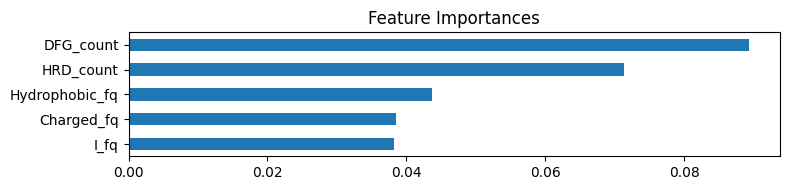

In [25]:
feature_importance = best_rf.feature_importances_
feature_names = X.columns
importances = pd.Series(best_rf.feature_importances_, index = X.columns).sort_values(ascending=True)
importances_filtered = importances[importances > 0.03]
fig, ax = plt.subplots(figsize=(8, len(importances_filtered) * 0.4))
importances_filtered.plot.barh(ax=ax)
ax.set_title('Feature Importances')
plt.tight_layout()
plt.show()

In [ ]:
results_df = pd.DataFrame({"Entry": entry_test,"Predicted_class": y_pred,"Actual_class": y_test})
print(results_df.head())